# Demo 1: Binary Classification with Logistic Regression (Diabetes Prediction) 🏥

<!---
This demo introduces binary classification through a practical health example: diabetes prediction. 
The goal is to help students understand:
1. How logistic regression works for binary classification
2. The importance of model evaluation in healthcare
3. How to interpret model results in a clinical context
4. Common pitfalls and best practices

Key teaching points:
- Start with a simple model (logistic regression) before moving to complex ones
- Focus on evaluation metrics relevant to health outcomes
- Emphasize the importance of model interpretability in healthcare
--->

This demo introduces binary classification using one of the simplest yet effective models: Logistic Regression. We'll use synthetic data resembling a diabetes prediction task - a common challenge in healthcare where early detection can significantly impact patient outcomes. The goal is to predict whether a patient has diabetes (1) or not (0) based on simulated health metrics.

> 💡 **Real-World Context**: In clinical practice, machine learning models can help screen patients for diabetes risk, enabling early intervention. However, the consequences of false negatives (missing a diabetes case) can be serious, so we need to carefully evaluate our model's performance.

## 0. Setup: Install Required Packages 📦

In [1]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Setup: Import Libraries 📚

<!---
Take time to explain each library's purpose. Many students struggle with understanding 
when to use which library. Emphasize that these are standard tools in the data scientist's toolkit.
--->

We start by importing the necessary Python libraries.

- `numpy` for numerical operations.
- `pandas` for data manipulation (DataFrames).
- `matplotlib.pyplot` and `seaborn` for plotting.
- `sklearn.model_selection` for splitting data.
- `sklearn.linear_model` for the Logistic Regression model.
- `sklearn.metrics` for evaluating the model (accuracy, confusion matrix, classification report, ROC curve, AUC).
- `sklearn.datasets` to generate synthetic data easily.
- `IPython.display` for displaying output in Jupyter notebooks.
Setting a random seed (`np.random.seed`) ensures that our results are reproducible – if we run the code again, the synthetic data generated will be the same.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.datasets import make_classification

# Configure plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42) # for reproducibility

## 2. Generate Synthetic Diabetes Data 🔄

<!---
Explain why we're using synthetic data:
1. Real health data often has privacy constraints
2. Synthetic data lets us control the complexity
3. Students can experiment without risk
4. The patterns we generate mimic real clinical data
--->

Real health data is complex and often restricted by privacy regulations (HIPAA). For this introductory demo, we'll use `make_classification` to generate synthetic data that mimics a diabetes prediction scenario.

> 🔬 **Clinical Features**: In real diabetes screening, key indicators include:
>
> - Fasting blood glucose levels
> - Body Mass Index (BMI)
> - Age
> - Blood pressure
> - Cholesterol levels

We create:

- `X`: Features (e.g., simulated glucose level, BMI, age). We'll create 1000 samples with 5 features.
- `y`: Target variable (0 for no diabetes, 1 for diabetes).
We specify `n_informative=3` meaning only 3 out of 5 features actually help predict the outcome, adding some realism. `flip_y=0.05` introduces a small amount of label noise (5% incorrect labels), also common in real datasets.
Finally, we convert the data into a pandas DataFrame for easier handling.

In [3]:
# Generate synthetic data for a binary classification problem
X, y = make_classification(
    n_samples=1000,      # Number of patients
    n_features=5,        # Number of health indicators (e.g., glucose, BMI, age, bp, cholesterol)
    n_informative=3,     # Number of features that actually predict diabetes
    n_redundant=1,       # Number of features that are linear combinations of informative features
    n_clusters_per_class=1, # How features group for each class
    weights=[0.8, 0.2],  # 80% non-diabetic (0), 20% diabetic (1) -> Imbalanced data!
    flip_y=0.05,         # Introduce some noise in labels
    random_state=42
)

# Create a pandas DataFrame
feature_names = ['Glucose', 'BMI', 'Age', 'BP', 'Cholesterol']
df = pd.DataFrame(X, columns=feature_names)
df['Diabetes'] = y

display("Synthetic Dataset Shape:", df.shape)
display("\nFirst 5 rows:")
display(df.head())
display("\nClass distribution:")
display(df['Diabetes'].value_counts(normalize=True))

'Synthetic Dataset Shape:'

(1000, 6)

'\nFirst 5 rows:'

,Glucose,BMI,Age,BP,Cholesterol,Diabetes
0,0.140006,-1.278683,1.013456,-0.445086,1.271190,0
1,0.309343,-0.653146,-0.264171,-1.568305,0.523643,0
2,-0.064040,-1.285786,-0.639231,0.345863,1.253569,0
3,0.141188,-1.192766,1.300527,-0.353426,1.224845,0
4,0.263424,-0.682904,0.338698,-1.817264,0.389505,0


'\nClass distribution:'

Diabetes
0    0.786
1    0.214
Name: proportion, dtype: float64

## 3. Explore the Data 🔍

<!---
Data exploration is crucial in healthcare:
1. Helps identify potential biases in the data
2. Reveals relationships between health indicators
3. Can suggest which features might be most predictive
4. Helps catch data quality issues early
--->

Before modeling, it's crucial to understand our data. In healthcare, this step is especially important as it can reveal:

- Potential biases in patient demographics
- Clinically meaningful relationships between health indicators
- Data quality issues that could affect patient care

We'll use `pairplot` from seaborn to visualize relationships between features and how they differ between diabetic and non-diabetic cases.

> 🔍 **Clinical Insight**: Look for patterns that match medical knowledge. For example, we expect higher glucose levels to be associated with diabetes diagnosis.

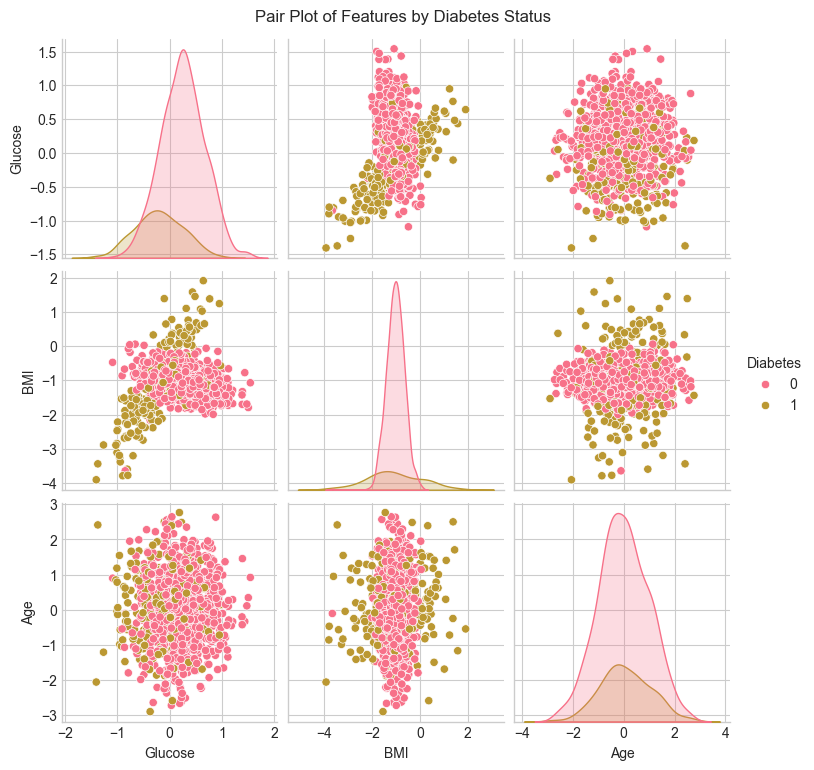

In [4]:
# Visualize relationships between features, colored by the target variable
sns.pairplot(df, hue='Diabetes', vars=feature_names[:3]) # Plot first 3 features for simplicity
plt.suptitle('Pair Plot of Features by Diabetes Status', y=1.02)
plt.show()

## 4. Split Data into Training and Testing Sets 📊

<!---
Emphasize why proper validation is crucial in healthcare:
1. Models will be used to make real clinical decisions
2. Need to ensure reliability across different patient populations
3. Testing set simulates using the model on new patients
4. Stratification preserves disease prevalence in both sets
--->

In healthcare applications, we must be especially careful to validate our models properly - they may eventually influence clinical decisions. We split our dataset into:

- Training set (80%): Used to train the Logistic Regression model
- Testing set (20%): Simulates using the model on new, unseen patients

> ⚕️ **Clinical Practice**: In real clinical validation, we often want to test models across different:
>
> - Hospitals/clinics
> - Patient demographics
> - Time periods
> This helps ensure the model works reliably in diverse healthcare settings.

In [5]:
# Separate features (X) and target (y)
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # Ensure reproducibility
    stratify=y        # Keep class proportions consistent in splits
)

display("Training set shape:", X_train.shape)
display("Testing set shape:", X_test.shape)

'Training set shape:'

(800, 5)

'Testing set shape:'

(200, 5)

## 5. Train a Logistic Regression Model 🧮

<!---
Key points about logistic regression in healthcare:
1. Simple but interpretable - doctors can understand it
2. Outputs probabilities - useful for risk assessment
3. Fast to train and deploy
4. Can be updated with new data
--->

Logistic Regression is an excellent starting point for clinical prediction models because:

- It's interpretable (clinicians can understand how it makes decisions)
- It outputs probabilities (useful for risk assessment)
- It's computationally efficient (can be quickly updated with new data)
- It serves as a baseline for comparing more complex models

> 🏥 **Healthcare Application**: Many clinical prediction rules (like CHADS₂ for stroke risk) are essentially simple scoring systems similar to logistic regression.

In [6]:
# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Train the model on the training data
display("Training the Logistic Regression model...")
log_reg.fit(X_train, y_train)
display("Model training complete.")

'Training the Logistic Regression model...'

'Model training complete.'

## 6. Make Predictions on the Test Set 🎯

<!---
Discuss the importance of prediction thresholds:
1. Different thresholds for different clinical contexts
2. Trade-off between catching cases and false alarms
3. Cost of false positives vs false negatives
4. Role of clinical judgment alongside model predictions
--->

With our trained model, we can now predict diabetes risk for new patients. In clinical practice, we might:

- Use different probability thresholds for screening vs. diagnosis
- Consider the cost of false positives (unnecessary tests) vs. false negatives (missed cases)
- Combine model predictions with clinical judgment

> ⚖️ **Clinical Trade-off**: Setting a lower probability threshold catches more potential cases but generates more false alarms. The right balance depends on:
>
> - Available healthcare resources
> - Cost and invasiveness of follow-up tests
> - Severity of missing a diagnosis

In [7]:
# Use the trained model to predict diabetes status on the test set
y_pred = log_reg.predict(X_test)

display("Predictions made on the test set.")
# display("First 10 predictions:", y_pred[:10])
# display("Actual first 10 labels:", y_test.values[:10])

'Predictions made on the test set.'

## 7. Evaluate the Model 📈

<!---
Emphasize healthcare-specific evaluation:
1. Different metrics matter for different clinical goals
2. Need to consider clinical impact of errors
3. Importance of subgroup analysis
4. Role of confidence intervals in healthcare
--->

In healthcare, model evaluation goes beyond simple accuracy. We need to consider:

**Clinical Impact Metrics:**

- **Sensitivity/Recall**: How many actual diabetes cases do we catch?
- **Specificity**: How well do we identify healthy patients?
- **Positive Predictive Value**: How reliable are our "high risk" flags?

> 🎯 **Target Metrics**: For diabetes screening, we might prioritize:
>
> - High sensitivity (>90%) to catch most cases
> - Acceptable specificity (>70%) to limit unnecessary testing
> - Good calibration of risk probabilities

'Accuracy: 0.9300'

'\nConfusion Matrix:'

array([[150,   7],
       [  7,  36]])

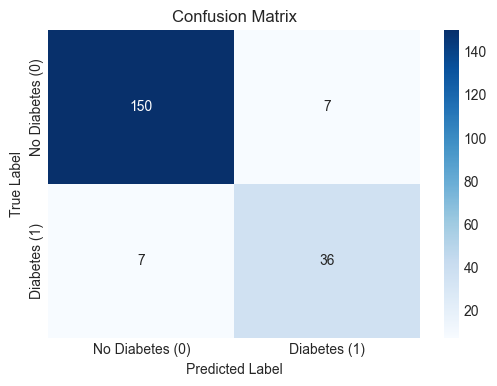

'\nClassification Report:'

'                 precision    recall  f1-score   support\n\nNo Diabetes (0)       0.96      0.96      0.96       157\n   Diabetes (1)       0.84      0.84      0.84        43\n\n       accuracy                           0.93       200\n      macro avg       0.90      0.90      0.90       200\n   weighted avg       0.93      0.93      0.93       200\n'

'\nAUC: 0.9277'

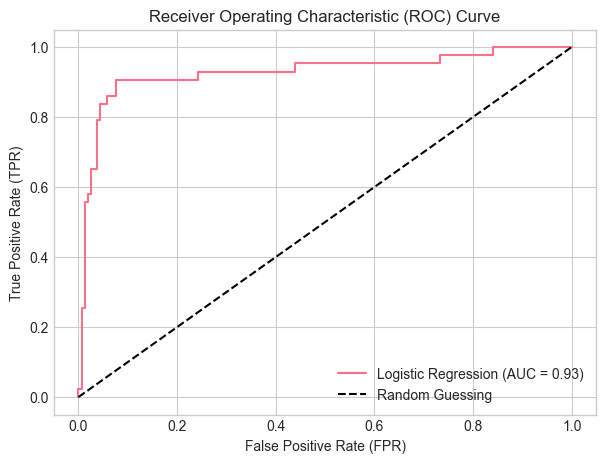

In [8]:
# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
display(f"Accuracy: {accuracy:.4f}")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
display("\nConfusion Matrix:")
display(cm)

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report
report = classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)'])
display("\nClassification Report:")
display(report)

# 4. ROC Curve and AUC
# Get prediction probabilities for the positive class (Diabetes=1)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
display(f"\nAUC: {auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') # Diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

## 8. Interpretation & Conclusion 🔬

Splitting data into training and testing sets ensures the model will work reliably on new patients, not just the ones it was trained on. In diabetes screening, false negatives (missing actual cases) are often more concerning than false positives, because delayed diagnosis can lead to serious complications; the confusion matrix’s bottom-left cell shows how many high-risk patients we would miss. AUC measures how well the model ranks positive vs. negative cases—e.g. an AUC of 0.9 means it correctly orders a random diabetic above a random non-diabetic about 90% of the time.

In practice, model performance should be compared to current clinical practice and minimum requirements for screening tools. Clinical models should be validated on new data, updated as populations change, and assessed for fairness across subgroups.